<a href="https://colab.research.google.com/github/kalashjain9/Python-Notes/blob/main/Sales_Prediction_using_Linear_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
ashydv_advertising_dataset_path = kagglehub.dataset_download('ashydv/advertising-dataset')

print('Data source import complete.')


# Use of Linear Regression Machine Learning model to predict total sales features like money spent on Advertising/Marketing individual fields.

****Importing Libraries****

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

**Load Dataset**

In [3]:
data = pd.read_csv('/content/advertising.csv')

In [4]:
data

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9
...,...,...,...,...
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5


**Domain Analysis**
 - Sales is target.
 - TV, Radio and Newspaper are input variables.
 - Dataset tells us about total sales made by company by inveting certain amount on TV, Radio & Newspaper advertisement.

**Basic Checks**

In [5]:
data.shape

(200, 4)

In [6]:
# head
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,12.0
3,151.5,41.3,58.5,16.5
4,180.8,10.8,58.4,17.9


In [7]:
# tail
data.tail()

,TV,Radio,Newspaper,Sales
195,38.2,3.7,13.8,7.6
196,94.2,4.9,8.1,14.0
197,177.0,9.3,6.4,14.8
198,283.6,42.0,66.2,25.5
199,232.1,8.6,8.7,18.4


In [8]:
# info
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB


In [9]:
# describe
data.describe()

,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000
mean,147.042500,23.264000,30.554000,15.130500
std,85.854236,14.846809,21.778621,5.283892
min,0.700000,0.000000,0.300000,1.600000
25%,74.375000,9.975000,12.750000,11.000000
50%,149.750000,22.900000,25.750000,16.000000
75%,218.825000,36.525000,45.100000,19.050000
max,296.400000,49.600000,114.000000,27.000000


In [10]:
# checking for missing values
data.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [11]:
data.columns

Index(['TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

**Exploratory Data Analysis**

***1. Univariate Analysis***

<Axes: ylabel='Density'>

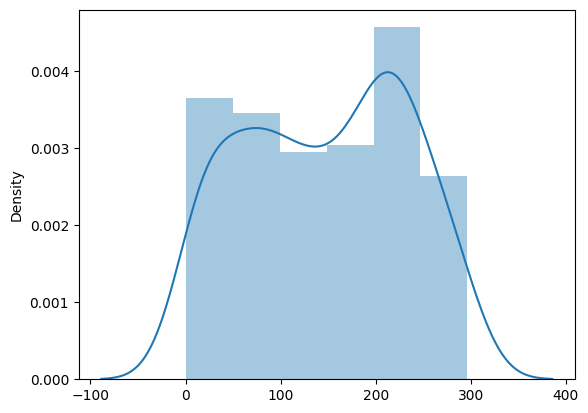

In [12]:
# checking distribution of TV
sns.distplot(x = data.TV, kde=True)

<Axes: ylabel='Density'>

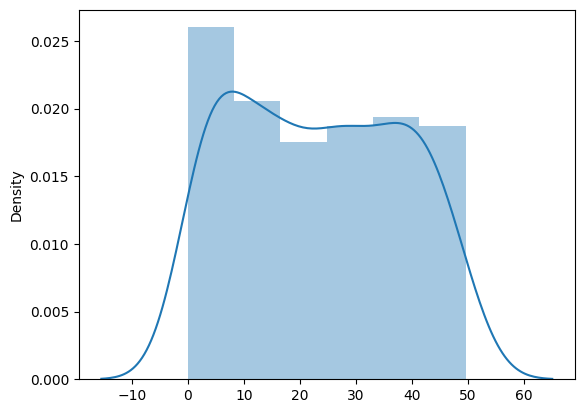

In [13]:
# checking distribution of Radio
sns.distplot(x = data.Radio, kde=True)

<Axes: ylabel='Density'>

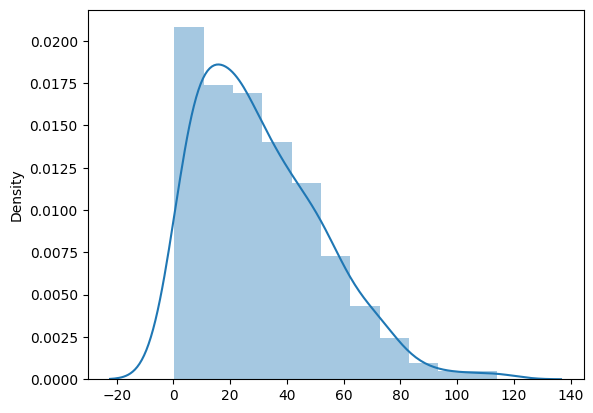

In [14]:
# checking distribution of Newspaper
sns.distplot(x = data.Newspaper, kde=True)

<Axes: ylabel='Density'>

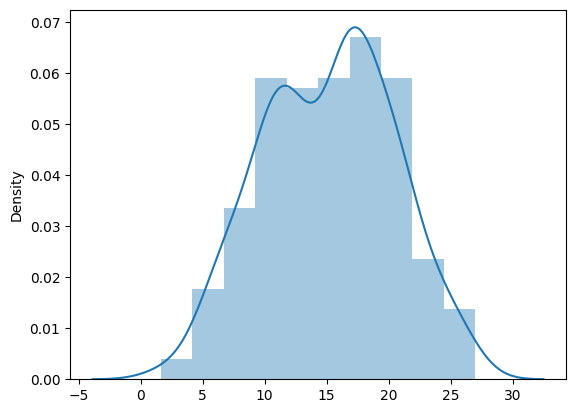

In [15]:
# checking distribution of Sales
sns.distplot(x = data.Sales, kde=True)

In [ ]:
# Insights
# Sales represent normal distribution
# TV, Radio & Newspaper are not representing normal distribution

***2. Bivariate Analysis***

<Axes: xlabel='TV', ylabel='Sales'>

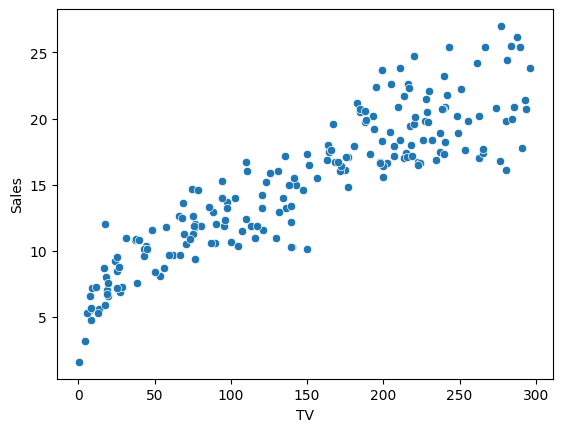

In [16]:
# Analyzing amount spent on TV with respect to Sales
sns.scatterplot(data = data, x = 'TV', y = 'Sales')

<Axes: xlabel='Radio', ylabel='Sales'>

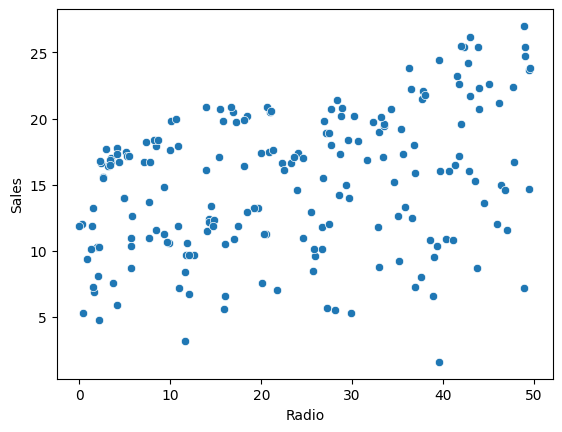

In [17]:
# Analyzing amount spent on Radio with respect to Sales
sns.scatterplot(data = data, x = 'Radio', y = 'Sales')

<Axes: xlabel='Newspaper', ylabel='Sales'>

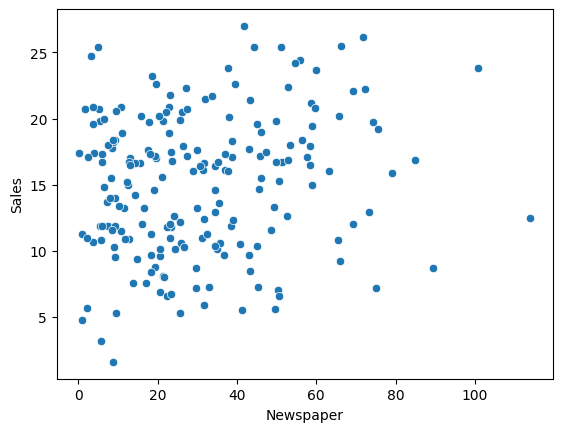

In [18]:
# Analyzing amount spent on Newspaper with respect to Sales
sns.scatterplot(data = data, x = 'Newspaper', y = 'Sales')

In [19]:
# From above all plots TV shows best advertisement trends among all TV, Radio & Newspaper.

***3. Multivariate Analysis***

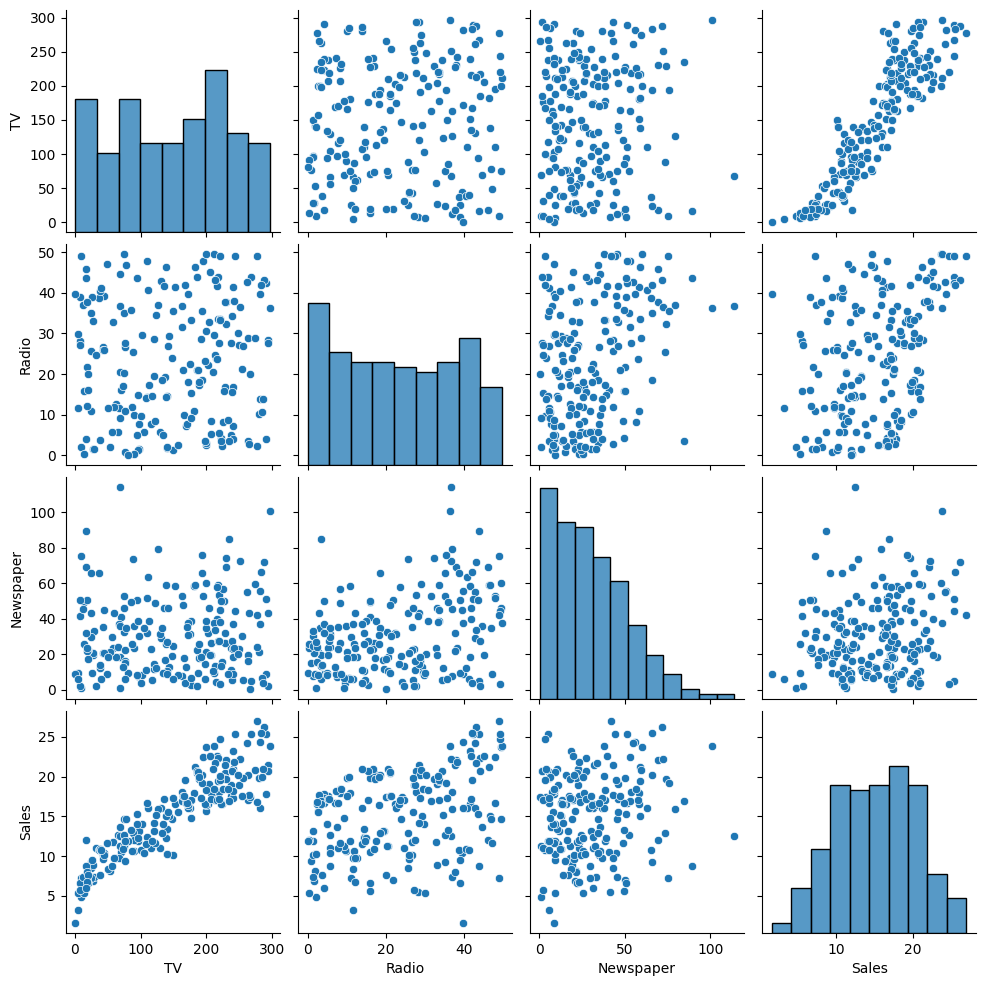

In [20]:
sns.pairplot(data)

**Data preprocessing**

In [21]:
# checking missing values
data.isnull().sum()

,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [22]:
# checking duplicates
data.duplicated().sum()

np.int64(0)

In [23]:
# data types
data.dtypes

,0
TV,float64
Radio,float64
Newspaper,float64
Sales,float64


*Checking for outliers*

<Axes: xlabel='TV'>

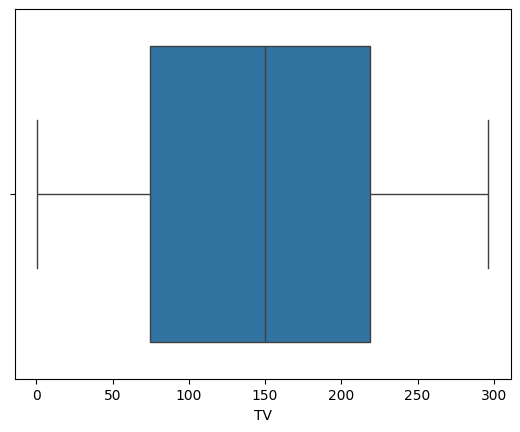

In [24]:
# check outliers in TV
sns.boxplot(x = data.TV)

<Axes: xlabel='Radio'>

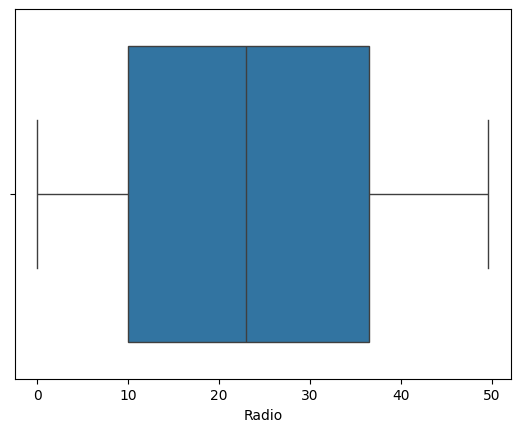

In [25]:
# check outliers in Radio
sns.boxplot(x = data.Radio)

<Axes: xlabel='Newspaper'>

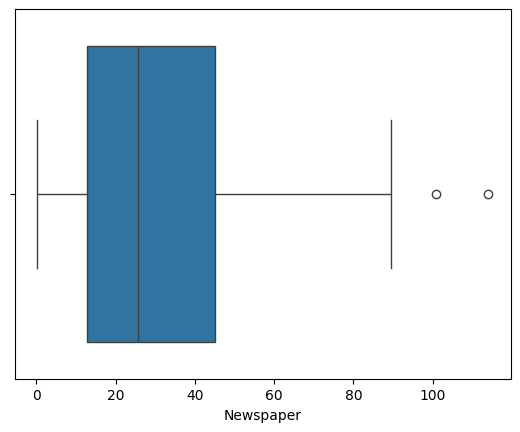

In [26]:
# check outliers in Newspaper
sns.boxplot(x = data.Newspaper)

In [ ]:
# Hence, from above analysis it is clear that Newspaper has outliers so we need to handle it.
# Newspaper has no nomarmal distribution, so will use IQR.

In [27]:
# Find Q1 & Q2
Q1 = data['Newspaper'].quantile(0.25)
Q3 = data['Newspaper'].quantile(0.75)

In [28]:
# Find IQR
IQR = Q3 - Q1
IQR

np.float64(32.35)

In [29]:
# find lower limit and upper limit
lower_limit = Q1 - 1.5*IQR
upper_limit = Q3 + 1.5*IQR
print('Lower Limit : ',lower_limit)
print('Upper Limit : ',upper_limit)

Lower Limit :  -35.775000000000006
Upper Limit :  93.625


In [30]:
# find values above upper limit
data.loc[data['Newspaper'] > upper_limit]

,TV,Radio,Newspaper,Sales
16,67.8,36.6,114.0,12.5
101,296.4,36.3,100.9,23.8


In [31]:
# find values above upper limit
data.loc[data['Newspaper'] < lower_limit]

,TV,Radio,Newspaper,Sales


In [32]:
# Since data is not normal will replace outliers with median
data.loc[data['Newspaper'] > upper_limit, 'Newspaper'] = data['Newspaper'].median()

<Axes: xlabel='Newspaper'>

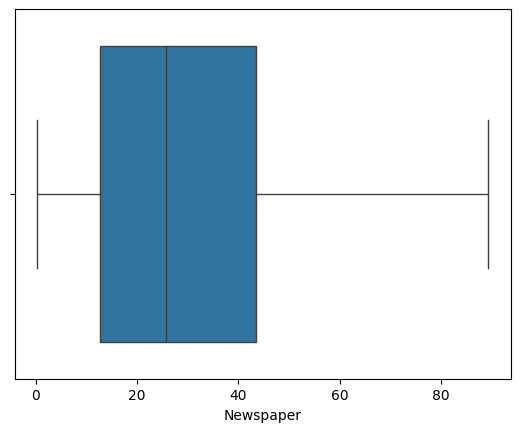

In [33]:
# Check are there any outliers in the Newspaper
sns.boxplot(x = data.Newspaper)

**Feature Engineering**

In [34]:
# drop irrelevant coumns
# select best features
# drop columns which has very less correlation with target variables
# drop one of the column if two input variables have high correlation

In [35]:
data.corr()

,TV,Radio,Newspaper,Sales
TV,1.000000,0.054809,0.048462,0.901208
Radio,0.054809,1.000000,0.343141,0.349631
Newspaper,0.048462,0.343141,1.000000,0.149471
Sales,0.901208,0.349631,0.149471,1.000000


<Axes: >

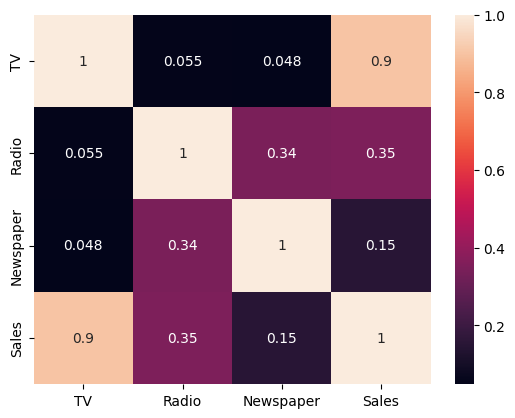

In [36]:
sns.heatmap(data.corr(), annot = True)

<Axes: >

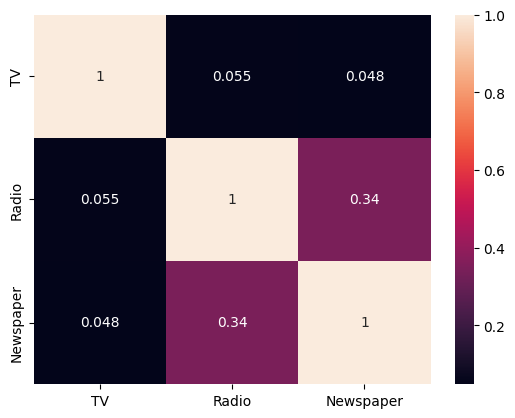

In [37]:
# check for multicolinearity
sns.heatmap(data.drop('Sales', axis = 1).corr(), annot = True)

**Splitting of data**

In [38]:
x = data.drop('Sales', axis = 1)
y = data['Sales']

**Splitting data for training and testing**

In [39]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(x, y, train_size = 0.7, test_size = 0.3, random_state = 4)

In [40]:
# Shapes with respect each data
print('x_train : ',x_train.shape)
print('x_test  : ',x_test.shape)
print('y_train : ',y_train.shape)
print('x_test  : ',y_train.shape)

x_train :  (140, 3)
x_test  :  (60, 3)
y_train :  (140,)
x_test  :  (140,)


**Model Building**

In [41]:
# import linear regression model
from sklearn.linear_model import LinearRegression

# initialize the model
model = LinearRegression()

# train model with x_train, y_train
model.fit(x_train, y_train)

LinearRegression()

*Predictions*

In [42]:
# make predictions
y_pred = model.predict(x_test)
y_pred

array([18.71043432, 16.28430979, 21.50568983, 24.65836595, 11.13565699,
       21.61801028, 12.46867806, 14.76770525, 12.20210642, 17.93950167,
       23.22932996, 18.12752368,  9.86752342, 14.83409711, 20.62411313,
       21.55945182, 21.05553445, 15.79811187,  9.65351233, 20.61877001,
       18.16850921, 20.91257102, 22.8515887 , 10.02616016, 21.85760616,
       20.5219519 , 15.73820609, 11.13425145, 19.13422857, 10.94247387,
       11.54504499, 10.52649538, 16.44733565, 16.48986546, 18.01652977,
        7.39360566, 17.28064515, 12.92281792, 17.12110888, 12.1393306 ,
       15.37704564, 10.70797828, 13.44308418,  9.12189079,  6.96947563,
       15.53303806, 18.68800482, 13.71407614,  9.6508032 , 20.86993178,
       17.87114904, 16.98003816, 12.07650683, 15.09322902, 10.38013732,
       11.00696185, 20.33147343, 10.21180192,  6.08363161,  9.36496848])

In [43]:
y_test

,Sales
11,17.4
99,17.2
128,24.7
175,27.0
1,10.4
111,21.8
90,14.0
177,16.7
88,12.9
187,17.3


In [44]:
# Coeffiecients of x
model.coef_

array([0.05410267, 0.09977449, 0.00260213])

In [45]:
# intercept c
model.intercept_

np.float64(4.689594410362195)

In [47]:
# Making predictions when TV = 100, Radio = 50, Newspaper = 10
model.predict([[100,50,10]])

array([15.11460743])

**Evaluate the model**

In [48]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [49]:
# MAE
MAE = mean_absolute_error(y_test, y_pred)
MAE

1.1351236540660672

In [50]:
# MSE
MSE = mean_squared_error(y_test, y_pred)
MSE

2.1201973497775857

In [51]:
# RMSE
RMSE = np.sqrt(MSE)
RMSE

np.float64(1.4560897464708642)

In [52]:
# r2_score
r2_score(y_test, y_pred)

0.9169369017627684